# Triangulo Estambre

Autor: Thanos Drossos

### Tarea: 
Cubrir un triangulo equilatero de lado l = 20 cm
con un segmento de estambre de 70cm, con la restriccion
De cubrir la mayor area y tratando de que el mapeo sea
1 a 1 y continuo.


## Explicación del Algoritmo

- El algoritmo determina la configuración óptima para cubrir un triángulo equilátero con un estambre de longitud fija

- Se fundamenta en principios de optimización geométrica para maximizar el área cubierta

- Utiliza el teorema isoperimétrico: entre todas las figuras con un perímetro fijo, el círculo maximiza el área

- Implementa la optimización matemática mediante scipy.optimize.minimize para calcular parámetros óptimos

## Caso 1: Estambre ≥ Perímetro del Triángulo (70cm)
L = 20cm

Estambre de longitud 70cm


- La estrategia óptima es trazar primero el perímetro completo del triángulo (60cm)

- El hilo restante (10cm) se utiliza para una línea interna desde un vértice hacia el centro

- Se logra cubrir el 100% del área del triángulo más una fracción adicional definida por la línea interna

- La continuidad del mapeo 1:1 se mantiene en todo el recorrido

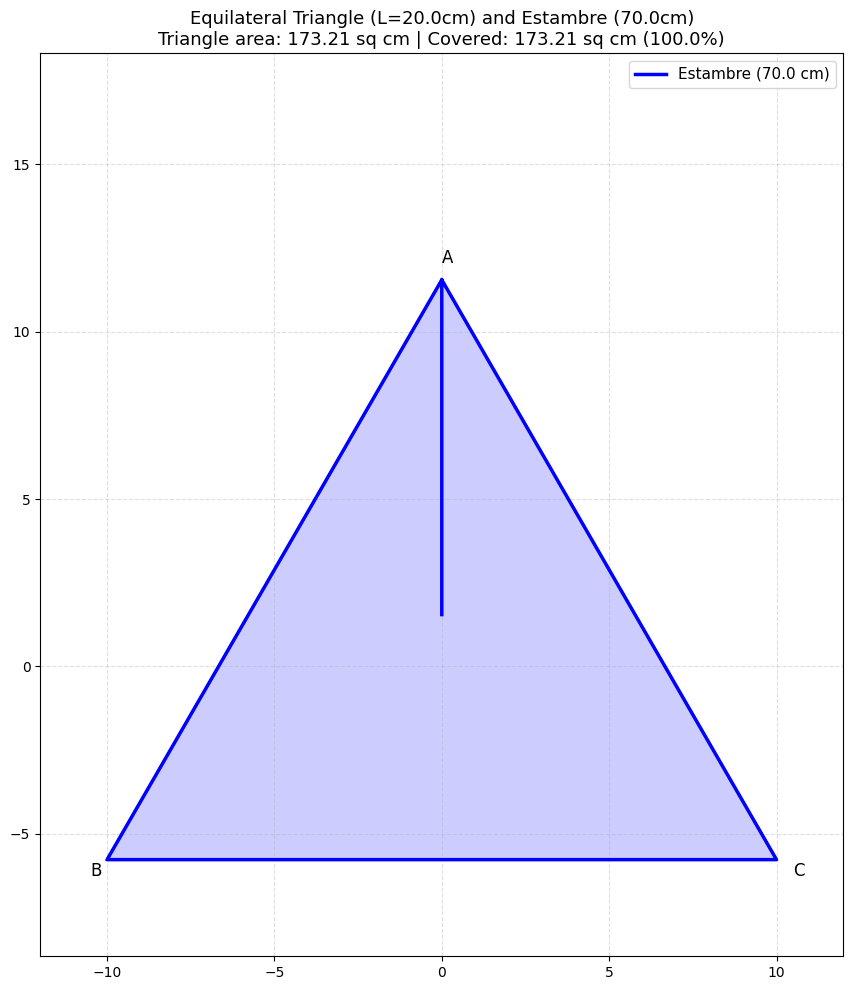

Triangle side length: 20.0 cm
Triangle perimeter: 60.0 cm
Total estambre length: 70.0 cm
Covered approximately 100.0% of the triangle area


In [36]:
result = plot_triangle_estambre(20, 70)  # Original case (70cm thread)
print(f"Triangle side length: {result['triangle_side_length']:.1f} cm")
print(f"Triangle perimeter: {result['triangle_perimeter']:.1f} cm")
print(f"Total estambre length: {result['estambre_length']:.1f} cm")
print(f"Covered approximately {result['coverage_percentage']:.1f}% of the triangle area")

## Caso 2: Caso Intermedio (50cm)
L = 20cm

Estambre de longitud 50cm



- Se genera una figura híbrida que combina propiedades de círculo y triángulo

- La forma óptima mantiene proporciones circulares donde es posible (para maximizar área)

- En puntos donde toca los bordes del triángulo, sigue segmentos rectos

- El radio óptimo se determina mediante optimización numérica

- Esta configuración logra cubrir aproximadamente el 92% del área del triángulo

- Representa un equilibrio matemáticamente preciso entre circularidad y adaptación al límite triangular

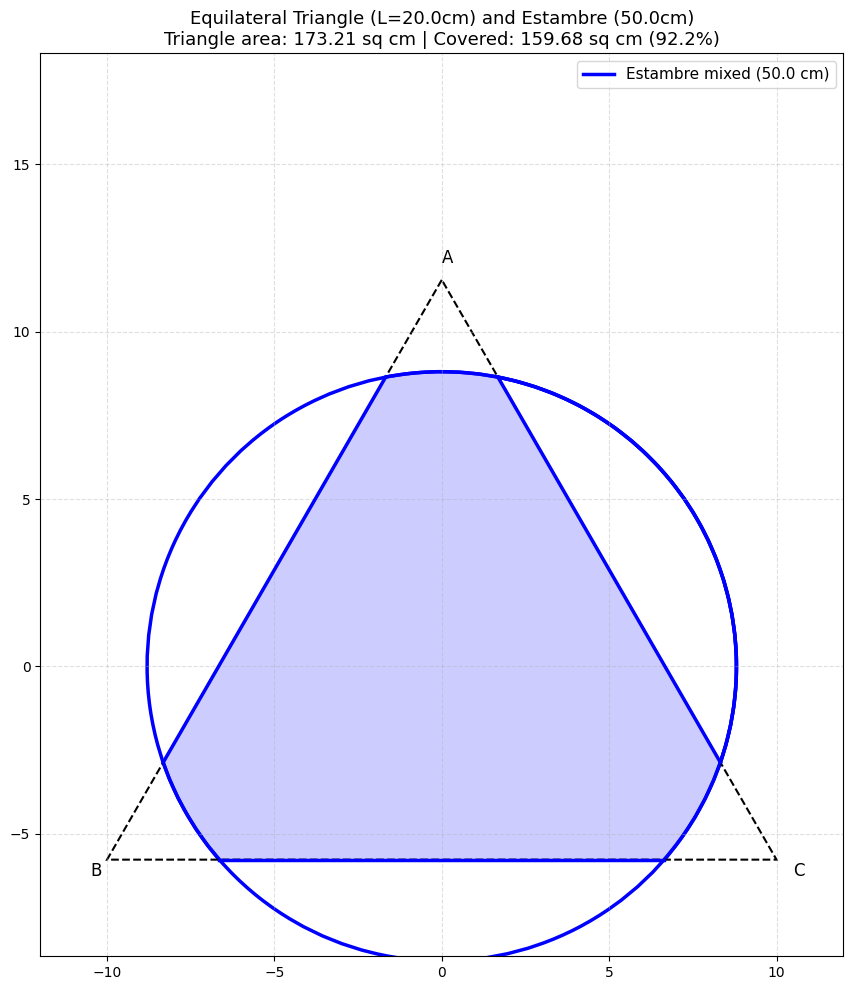

Triangle side length: 20.0 cm
Triangle perimeter: 60.0 cm
Total estambre length: 50.0 cm
Covered approximately 92.2% of the triangle area


In [37]:
result = plot_triangle_estambre(20, 50)
print(f"Triangle side length: {result['triangle_side_length']:.1f} cm")
print(f"Triangle perimeter: {result['triangle_perimeter']:.1f} cm")
print(f"Total estambre length: {result['estambre_length']:.1f} cm")
print(f"Covered approximately {result['coverage_percentage']:.1f}% of the triangle area")

## Caso 3: Estambre ≤ Perímetro del Círculo Inscrito (30cm)
L = 20cm

Estambre de longitud 30cm


- El círculo es la figura que maximiza el área para un perímetro dado

- El área cubierta representa aproximadamente el 41% del área total del triángulo

- La distribución circular es matemáticamente óptima para esta restricción

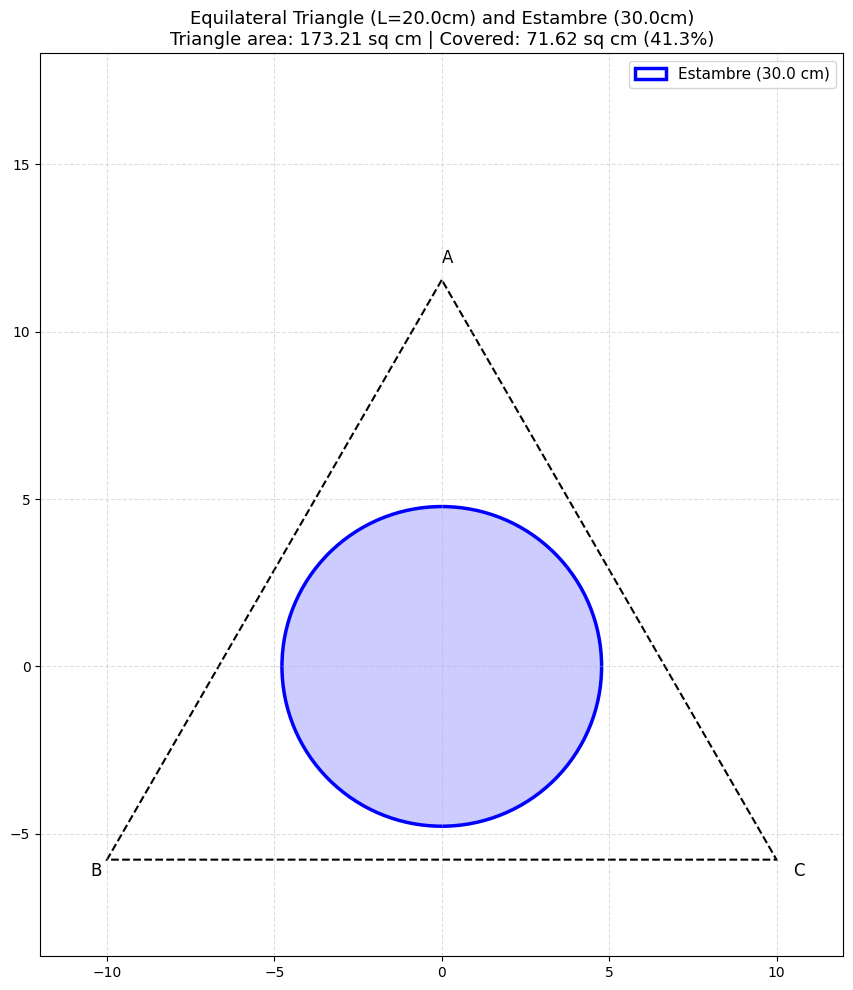

Triangle side length: 20.0 cm
Triangle perimeter: 60.0 cm
Total estambre length: 30.0 cm
Covered approximately 41.3% of the triangle area


In [38]:
result = plot_triangle_estambre(20, 30)  # Original case (70cm thread)
print(f"Triangle side length: {result['triangle_side_length']:.1f} cm")
print(f"Triangle perimeter: {result['triangle_perimeter']:.1f} cm")
print(f"Total estambre length: {result['estambre_length']:.1f} cm")
print(f"Covered approximately {result['coverage_percentage']:.1f}% of the triangle area")

## Codigo:

In [ ]:
import numpy as np
from matplotlib.patches import Polygon, Circle, Arc, PathPatch
import matplotlib.pyplot as plt
import matplotlib.path as mpath
from matplotlib.patches import Path
from matplotlib.collections import PatchCollection
from scipy.optimize import minimize

def plot_triangle_estambre(L, estambre_length, show_plot=True):
    """
    Plot an equilateral triangle covered with estambre (thread)
    
    Parameters:
    -----------
    L : float
        Side length of the equilateral triangle in cm
    estambre_length : float
        Length of the estambre (thread) in cm
    show_plot : bool
        Whether to display the plot (default: True)
    
    Returns:
    --------
    dict
        Dictionary containing information about the coverage
    """
    # Calculate triangle properties
    height = L * np.sqrt(3) / 2
    triangle_area = (L**2 * np.sqrt(3)) / 4

    # Define vertices of the equilateral triangle
    vertices = np.array([
        [0, 2*height/3],       # Top vertex (A)
        [-L/2, -height/3],     # Bottom left vertex (B)
        [L/2, -height/3]       # Bottom right vertex (C)
    ])

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 10))

    # Calculate the center of the triangle
    triangle_center = np.mean(vertices, axis=0)

    # Calculate the perimeter of the triangle
    triangle_perimeter = 3 * L

    # Calculate the incircle properties
    incircle_radius = height / 3
    incircle_center = triangle_center
    incircle_perimeter = 2 * np.pi * incircle_radius

    # Different cases based on estambre length
    if estambre_length >= triangle_perimeter:
        # Case 1: Enough thread to trace the full triangle with some left over
        
        # First add the triangle with shading to show it's covered by the thread
        ax.add_patch(Polygon(vertices, closed=True, alpha=0.2, facecolor='blue', edgecolor=None))
        
        # Calculate remaining thread
        remaining = estambre_length - triangle_perimeter
        
        # Prepare for the full estambre path (both perimeter and internal part)
        estambre_path = np.vstack([vertices, vertices[0]])  # Start with perimeter points
        
        # Add internal line with remaining thread if there is any
        if remaining > 0:
            # Create a line from where we ended back at vertex A towards the center
            start_point = vertices[0]  # Top vertex
            
            # Calculate maximum possible line length (min of remaining thread or distance to center)
            max_distance = np.linalg.norm(vertices[0] - triangle_center)
            line_length = min(remaining, max_distance)
            
            # Calculate direction vector from vertex A to center
            direction = (triangle_center - vertices[0]) / max_distance
            
            # Calculate end point
            end_point = vertices[0] + direction * line_length
            
            # Add this point to the estambre path
            estambre_path = np.vstack([estambre_path, end_point])
        
        covered_area = triangle_area
            
        # Draw the entire estambre path in a single color
        ax.plot(estambre_path[:, 0], estambre_path[:, 1], '-', color='blue', linewidth=2.5,
               label=f'Estambre ({estambre_length:.1f} cm)')
        
    elif estambre_length <= incircle_perimeter:
        # Case 2: Not enough thread to trace even the incircle
        # Place the largest possible circle inside
        
        # Calculate the radius of the largest circle we can draw with the given thread
        circle_radius = estambre_length / (2 * np.pi)
        
        # Make sure the circle doesn't exceed the incircle
        if circle_radius > incircle_radius:
            circle_radius = incircle_radius
        
        # Draw the circle as the estambre
        circle = Circle(incircle_center, circle_radius, fill=False, edgecolor='blue', 
                      linewidth=2.5, label=f'Estambre ({estambre_length:.1f} cm)')
        ax.add_patch(circle)
        
        # Fill the circle with light shading
        ax.add_patch(Circle(incircle_center, circle_radius, alpha=0.2, facecolor='blue', edgecolor=None))
        
        # Calculate covered area
        covered_area = np.pi * circle_radius**2
        
    else:
        # Case 3: Between incircle perimeter and triangle perimeter
        # Use a mixed shape that maximizes area while using all the estambre

        # The optimal shape will be a modified circle that follows the triangle edges
        # where necessary, with arcs connecting the straight segments
        
        # Instead of the previous approach, we'll start from a circular shape and
        # modify it to fit inside the triangle while maximizing area
        
        # First, calculate the distances from the center to each edge
        # For an equilateral triangle, all these distances are the same (height/3)
        center_to_edge = height / 3
        
        # Define a function to calculate the area and path of our shape based on the radius
        def calculate_shape(radius):
            """Calculate the shape properties for a given radius."""
            # If radius <= incircle_radius, it's just a circle
            if radius <= center_to_edge:
                return {
                    'type': 'circle',
                    'radius': radius,
                    'perimeter': 2 * np.pi * radius,
                    'area': np.pi * radius**2
                }
            
            # Otherwise, we need a mixed shape with arcs and straight segments
            # Calculate where the circle intersects each edge of the triangle
            intersections = []
            edge_lengths = []
            arc_angles = []
            
            # Calculate intersection points and angles for each edge
            for i in range(3):
                v1 = vertices[i]
                v2 = vertices[(i+1) % 3]
                
                # Direction vector from center to the middle of this edge
                edge_midpoint = (v1 + v2) / 2
                center_to_edge_dir = edge_midpoint - triangle_center
                center_to_edge_dir = center_to_edge_dir / np.linalg.norm(center_to_edge_dir)
                
                # Where the radius hits the edge
                hit_point = triangle_center + center_to_edge_dir * center_to_edge
                
                # Distance along the edge from midpoint to the hit point
                edge_dir = (v2 - v1) / np.linalg.norm(v2 - v1)
                edge_mid_to_hit = hit_point - edge_midpoint
                hit_dist_along_edge = np.dot(edge_mid_to_hit, edge_dir)
                
                # Angle subtended by this edge from the center
                # Proportional to how much of the perimeter follows the edge
                d = center_to_edge  # Distance from center to edge
                if radius <= d:
                    # Radius doesn't exceed triangle, no straight segment needed
                    intersections.append(None)
                    edge_lengths.append(0)
                    arc_angles.append(2 * np.pi / 3)  # 120 degrees for each third
                else:
                    # Calculate where the radius exceeds the triangle
                    # Project to find intersection points with the edge
                    # This is the half-length of the straight segment
                    half_segment = np.sqrt(radius**2 - d**2)
                    
                    # Store intersection points
                    int1 = hit_point - edge_dir * half_segment
                    int2 = hit_point + edge_dir * half_segment
                    intersections.append((int1, int2))
                    
                    # Store segment length
                    edge_lengths.append(2 * half_segment)
                    
                    # Calculate the arc angle (for the corners)
                    # The angle that's not covered by the straight segment
                    central_angle = 2 * np.arcsin(half_segment / radius)
                    arc_angle = 2 * np.pi / 3 - central_angle
                    arc_angles.append(arc_angle)
            
            # Calculate the total perimeter of this shape
            total_edge_length = sum(edge_lengths)
            total_arc_length = sum(arc_angles) * radius
            perimeter = total_edge_length + total_arc_length
            
            # Calculate area (approximation using circular sector formulas)
            # Base area is the entire circle
            area = np.pi * radius**2
            
            # Subtract the areas of the parts outside the triangle
            for i in range(3):
                if edge_lengths[i] > 0:
                    # Calculate the area of the segment outside the triangle
                    # This is the area between the arc and the straight line
                    chord_length = edge_lengths[i]
                    d = center_to_edge
                    
                    # Area of the circular segment
                    segment_area = (radius**2) * (arc_angles[i] - np.sin(arc_angles[i])) / 2
                    
                    # Subtract from total area (only the part outside the triangle)
                    outside_area = radius**2 * np.arcsin(chord_length/(2*radius)) - \
                                   (chord_length/2) * np.sqrt(radius**2 - (chord_length/2)**2)
                    area -= outside_area
            
            return {
                'type': 'mixed',
                'radius': radius,
                'perimeter': perimeter,
                'area': area,
                'edge_lengths': edge_lengths,
                'arc_angles': arc_angles,
                'intersections': intersections
            }
        
        # Define the objective function for optimization
        def objective_function(radius):
            shape = calculate_shape(radius)
            perimeter_diff = abs(shape['perimeter'] - estambre_length)
            
            # We want to maximize area while matching the perimeter
            # Adding a large penalty for perimeter mismatch
            penalty = 1000 * perimeter_diff
            return -shape['area'] + penalty
        
        # Use optimization to find the radius that gives us the target perimeter
        # and maximizes the area
        initial_radius = (estambre_length / (2 * np.pi))  # Start with circle
        bounds = [(initial_radius * 0.5, incircle_radius * 2)]
        result = minimize(objective_function, [initial_radius], bounds=bounds)
        optimal_radius = result.x[0]
        
        # Calculate the shape with the optimal radius
        optimal_shape = calculate_shape(optimal_radius)
        
        # Draw the shape
        if optimal_shape['type'] == 'circle':
            # Simple circle case
            circle = Circle(triangle_center, optimal_radius, fill=False, edgecolor='blue',
                          linewidth=2.5, label=f'Estambre ({estambre_length:.1f} cm)')
            ax.add_patch(circle)
            
            # Fill circle
            ax.add_patch(Circle(triangle_center, optimal_radius, alpha=0.2, facecolor='blue', edgecolor=None))
            
            covered_area = optimal_shape['area']
        else:
            # Mixed shape with arcs and straight segments
            # Draw the arcs
            start_angle = -np.pi/6  # Start from the top and go clockwise
            
            for i in range(3):
                if optimal_shape['intersections'][i] is None:
                    # No intersection with this edge, draw a full arc for this segment
                    arc = Arc(triangle_center, 2*optimal_radius, 2*optimal_radius,
                             theta1=np.degrees(start_angle),
                             theta2=np.degrees(start_angle + 2*np.pi/3),
                             color='blue', linewidth=2.5)
                    ax.add_patch(arc)
                else:
                    # Draw the arc in this corner
                    int1, int2 = optimal_shape['intersections'][i]
                    
                    # Calculate angles to the intersection points
                    angle1 = np.arctan2(int1[1] - triangle_center[1], int1[0] - triangle_center[0])
                    angle2 = np.arctan2(int2[1] - triangle_center[1], int2[0] - triangle_center[0])
                    
                    # Ensure we're drawing the right arc segment
                    if i == 0:  # Top section
                        if angle1 > angle2:
                            angle1, angle2 = angle2, angle1
                    elif i == 1:  # Left bottom section
                        if angle1 < angle2:
                            angle1, angle2 = angle2, angle1
                    else:  # Right bottom section
                        if angle1 > angle2:
                            angle1, angle2 = angle2, angle1
                    
                    arc = Arc(triangle_center, 2*optimal_radius, 2*optimal_radius,
                             theta1=np.degrees(angle1),
                             theta2=np.degrees(angle2),
                             color='blue', linewidth=2.5)
                    ax.add_patch(arc)
                    
                    # Draw the straight segment
                    ax.plot([int1[0], int2[0]], [int1[1], int2[1]], '-', color='blue', linewidth=2.5)
                
                # Move to the next segment
                start_angle += 2*np.pi/3
            
            # Create a polygon for filling the covered area
            # This is complex - we need to approximate by creating a polygon
            # with points along the arcs and straight segments
            polygon_points = []
            
            for i in range(3):
                if optimal_shape['intersections'][i] is None:
                    # Generate points along the arc
                    angle_start = i * 2*np.pi/3
                    angle_end = (i + 1) * 2*np.pi/3
                    arc_points = 20
                    for j in range(arc_points):
                        angle = angle_start + j * (angle_end - angle_start) / (arc_points - 1)
                        x = triangle_center[0] + optimal_radius * np.cos(angle)
                        y = triangle_center[1] + optimal_radius * np.sin(angle)
                        polygon_points.append([x, y])
                else:
                    int1, int2 = optimal_shape['intersections'][i]
                    # Add the first intersection point
                    polygon_points.append(int1)
                    # Add the straight segment
                    polygon_points.append(int2)
                    
                    # Calculate angles for the arc
                    angle1 = np.arctan2(int2[1] - triangle_center[1], int2[0] - triangle_center[0])
                    next_i = (i + 1) % 3
                    if optimal_shape['intersections'][next_i] is not None:
                        int3, _ = optimal_shape['intersections'][next_i]
                        angle2 = np.arctan2(int3[1] - triangle_center[1], int3[0] - triangle_center[0])
                    else:
                        angle2 = (i + 1) * 2*np.pi/3 + np.pi/6
                    
                    # Ensure we're drawing the right arc segment
                    if angle2 < angle1:
                        angle2 += 2*np.pi
                    
                    # Generate points along the arc
                    arc_points = 10
                    for j in range(1, arc_points):  # Start from 1 to avoid duplicating int2
                        angle = angle1 + j * (angle2 - angle1) / arc_points
                        x = triangle_center[0] + optimal_radius * np.cos(angle)
                        y = triangle_center[1] + optimal_radius * np.sin(angle)
                        polygon_points.append([x, y])
            
            # Convert to numpy array and create a filled polygon
            polygon_points = np.array(polygon_points)
            if len(polygon_points) > 0:
                coverage_poly = Polygon(polygon_points, closed=True, alpha=0.2,
                                      facecolor='blue', edgecolor=None)
                ax.add_patch(coverage_poly)
            
            covered_area = optimal_shape['area']
            
            # Add a label for this case
            ax.plot([], [], '-', color='blue', linewidth=2.5,
                  label=f'Estambre mixed ({estambre_length:.1f} cm)')

    # Plot the triangle outline on top so it's clearly visible
    triangle = Polygon(vertices, closed=True, fill=False, edgecolor='black', 
                     linestyle='--', linewidth=1.5)
    ax.add_patch(triangle)

    # Calculate coverage percentage
    coverage_percentage = (covered_area / triangle_area) * 100
    if coverage_percentage > 100:
        coverage_percentage = 100  # Cap at 100%

    # Annotations for vertices
    ax.annotate('A', vertices[0] + [0, 0.5], fontsize=12)
    ax.annotate('B', vertices[1] + [-0.5, -0.5], fontsize=12)
    ax.annotate('C', vertices[2] + [0.5, -0.5], fontsize=12)

    # Set up the plot
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_aspect('equal')
    ax.legend(loc='upper right', fontsize=11)
    ax.set_title(f'Equilateral Triangle (L={L:.1f}cm) and Estambre ({estambre_length:.1f}cm)\n'
                f'Triangle area: {triangle_area:.2f} sq cm | Covered: {covered_area:.2f} sq cm ({coverage_percentage:.1f}%)', 
                fontsize=13)

    # Adjust the view to show the entire triangle
    ax.set_xlim(-L/2-2, L/2+2)
    ax.set_ylim(-height/2, height+1)

    plt.tight_layout()
    
    if show_plot:
        plt.show()

    # Prepare results to return
    results = {
        "triangle_side_length": L,
        "triangle_perimeter": triangle_perimeter,
        "triangle_area": triangle_area,
        "estambre_length": estambre_length,
        "covered_area": covered_area,
        "coverage_percentage": coverage_percentage,
        "figure": fig,
        "axis": ax
    }
    
    return results

